# VLM vs VLM Stag Hunt Analysis

This notebook follows the structure of the adults unified notebook: Python for data preparation and plotting, then `rpy2`/`%%R` for mixed-effects models.

All descriptive and inferential analyses are split by `signalingPathType`, with one subplot or one model section each for:
- `equal-optimal`
- `costly-suboptimal`

Within each path type, the trial-level measures are organized by `utilityStructure`:
- `favor_hare`
- `tie`
- `favor_stag`

## 1. Imports, Paths, and Plot Style

In [1]:
import os
import warnings
from pathlib import Path

from IPython import get_ipython
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats

warnings.filterwarnings('ignore')

ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

UTILITY_ORDER = ['favor_hare', 'tie', 'favor_stag']
PATH_TYPE_ORDER = ['equal-optimal', 'costly-suboptimal']
SIGNALING_ORDER = ['non_signaling', 'signaling']
OUTCOME_ORDER = ['both_stag', 'both_rabbit', 'different_big_goals', 'player1_rabbit', 'player2_rabbit', 'nothing']

UTILITY_PALETTE = {
    'favor_hare': '#AA2B46',
    'tie': '#E58760',
    'favor_stag': '#F6DEA4'
}
SIGNALING_PALETTE = {
    'non_signaling': '#C9DEE5',
    'signaling': '#3B5DA3'
}
OUTCOME_PALETTE = {
    'both_stag': '#3B5DA3',
    'both_rabbit': '#E58760',
    'different_big_goals': '#6CB3DA',
    'player1_rabbit': '#F6DEA4',
    'player2_rabbit': '#C9DEE5',
    'nothing': '#B0B0B0'
}

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'font.family': 'Arial'
})

candidate_dirs = [
    Path('dataAnalysis/generated/stag_hunt_vlm_vs_vlm_n5'),
    Path('generated/stag_hunt_vlm_vs_vlm_n5')
]
OUTPUT_DIR = None
for candidate in candidate_dirs:
    if (candidate / 'trial_level.csv').exists():
        OUTPUT_DIR = candidate
        break

if OUTPUT_DIR is None:
    raise FileNotFoundError(
        'Missing simulation output in any expected directory: ' + ', '.join(str(path) for path in candidate_dirs)
    )

TRIAL_PATH = OUTPUT_DIR / 'trial_level.csv'
RUN_PATH = OUTPUT_DIR / 'run_summary.csv'
SUMMARY_PATH = OUTPUT_DIR / 'analysis_summary.csv'
SIGNAL_COMPARISON_PATH = OUTPUT_DIR / 'signal_comparison_summary.csv'

print(f'Using output directory: {OUTPUT_DIR.resolve()}')


Using output directory: /Users/chengshaozhe/Documents/DukeECClab/code/multiplePlayerGridGame_socketIO/.claude/worktrees/naughty-mirzakhani/dataAnalysis/generated/stag_hunt_vlm_vs_vlm_n5


## 2. Data Loading and Trial-Level Validation

In [2]:
trial_df = pd.read_csv(TRIAL_PATH)
run_df = pd.read_csv(RUN_PATH)

for col in ['stagHuntSuccess', 'collaborationSucceeded', 'signalerChoseSignalingPath', 'invalidOffGoalAction']:
    trial_df[col] = trial_df[col].astype(bool)

trial_df['signalingPathType'] = pd.Categorical(trial_df['signalingPathType'], categories=PATH_TYPE_ORDER, ordered=True)
trial_df['utilityStructure'] = pd.Categorical(trial_df['utilityStructure'], categories=UTILITY_ORDER, ordered=True)
trial_df['signalingLabel'] = pd.Categorical(
    np.where(trial_df['signalerChoseSignalingPath'], 'signaling', 'non_signaling'),
    categories=SIGNALING_ORDER,
    ordered=True
)
trial_df['outcomeCategory'] = pd.Categorical(trial_df['outcomeCategory'], categories=OUTCOME_ORDER)
trial_df['totalMoves'] = trial_df['player1MoveCount'] + trial_df['player2MoveCount']
trial_df['signalerChoseSignalingPathInt'] = trial_df['signalerChoseSignalingPath'].astype(int)
trial_df['stagHuntSuccessInt'] = trial_df['stagHuntSuccess'].astype(int)

assert len(trial_df) == 5 * 18, f'Expected 90 trial rows, found {len(trial_df)}'
assert len(run_df) == 5, f'Expected 5 run rows, found {len(run_df)}'
assert trial_df['mapId'].nunique() == 18, f"Expected 18 unique maps, found {trial_df['mapId'].nunique()}"
assert (trial_df.groupby('mapId').size() == 5).all(), 'Each map should appear exactly 5 times'
assert set(trial_df['signalingPathType'].dropna().unique()) == set(PATH_TYPE_ORDER), 'Missing path type(s)'
assert set(trial_df['utilityStructure'].dropna().unique()) == set(UTILITY_ORDER), 'Missing utility structure(s)'
assert (~trial_df['invalidOffGoalAction']).all(), 'Found invalid off-goal actions in trial data'
assert np.allclose(trial_df['teamRoundPoints'], trial_df['player1RoundPoints'] + trial_df['player2RoundPoints']), 'teamRoundPoints mismatch'
assert np.allclose(trial_df['utilityDeltaStagMinusHare'], trial_df['stagFinalUtility'] - trial_df['hareFinalUtility']), 'utility delta mismatch'
assert (trial_df.groupby('runId')['teamTotalPoints'].diff().fillna(0) >= 0).all(), 'teamTotalPoints must be monotone within run'

display(trial_df.head())
display(
    trial_df.groupby(['signalingPathType', 'utilityStructure']).size().rename('trialCount').reset_index()
)
print('Trial-level validation complete.')


,runId,trialIndexWithinRun,mapId,seed,agentTypePlayer1,agentTypePlayer2,temperature,experimentType,player1Role,player2Role,...,trialEstimatedCostUsd,pricingModel,player1BaseModel,player2BaseModel,player1VlmCalls,player2VlmCalls,signalingLabel,totalMoves,signalerChoseSignalingPathInt,stagHuntSuccessInt
0,1,1,1,20261421,vlm,vlm,0,StagHunt,Non-Signaler,Signaler,...,0,vlm,NaN,NaN,0,0,non_signaling,0,0,0
1,1,2,2,20261422,vlm,vlm,0,StagHunt,Signaler,Non-Signaler,...,0,vlm,NaN,NaN,0,0,non_signaling,0,0,0
2,1,3,3,20261423,vlm,vlm,0,StagHunt,Non-Signaler,Signaler,...,0,vlm,NaN,NaN,0,0,non_signaling,0,0,0
3,1,4,4,20261424,vlm,vlm,0,StagHunt,Signaler,Non-Signaler,...,0,vlm,NaN,NaN,0,0,non_signaling,0,0,0
4,1,5,5,20261425,vlm,vlm,0,StagHunt,Non-Signaler,Signaler,...,0,vlm,NaN,NaN,0,0,non_signaling,0,0,0


,signalingPathType,utilityStructure,trialCount
0,equal-optimal,favor_hare,15
1,equal-optimal,tie,15
2,equal-optimal,favor_stag,15
3,costly-suboptimal,favor_hare,15
4,costly-suboptimal,tie,15
5,costly-suboptimal,favor_stag,15


Trial-level validation complete.


## 3. Descriptive Summaries and Output Tables

In [3]:
def ci95(series):
    values = pd.Series(series).dropna().astype(float)
    if len(values) <= 1:
        return 0.0
    return float(stats.sem(values) * stats.t.ppf(0.975, len(values) - 1))

def save_figure(fig, filename):
    path = OUTPUT_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches='tight')
    display(fig)
    print(f'Saved {path}')
    plt.close(fig)

analysis_summary_df = (
    trial_df.groupby(['signalingPathType', 'utilityStructure'])
    .agg(
        trialCount=('mapId', 'size'),
        signalingRate=('signalerChoseSignalingPathInt', 'mean'),
        stagSuccessRate=('stagHuntSuccessInt', 'mean'),
        meanTeamRoundPoints=('teamRoundPoints', 'mean'),
        meanTeamUtility=('teamUtility', 'mean'),
        meanSteps=('steps', 'mean')
    )
    .reset_index()
)

outcome_summary = (
    trial_df.groupby(['signalingPathType', 'utilityStructure', 'outcomeCategory']).size()
    .rename('count')
    .reset_index()
)
outcome_summary['proportion'] = outcome_summary.groupby(['signalingPathType', 'utilityStructure'])['count'].transform(lambda s: s / s.sum())
outcome_wide = outcome_summary.pivot_table(
    index=['signalingPathType', 'utilityStructure'],
    columns='outcomeCategory',
    values='count',
    fill_value=0
)
outcome_wide.columns = [f'{col}Count' for col in outcome_wide.columns]
analysis_summary_df = analysis_summary_df.merge(outcome_wide.reset_index(), on=['signalingPathType', 'utilityStructure'], how='left')

signal_comparison_df = (
    trial_df.groupby(['signalingPathType', 'utilityStructure', 'signalingLabel'])
    .agg(
        trialCount=('mapId', 'size'),
        stagSuccessRate=('stagHuntSuccessInt', 'mean'),
        meanTeamRoundPoints=('teamRoundPoints', 'mean'),
        meanTeamUtility=('teamUtility', 'mean')
    )
    .reset_index()
)

analysis_summary_df.to_csv(SUMMARY_PATH, index=False)
signal_comparison_df.to_csv(SIGNAL_COMPARISON_PATH, index=False)

display(analysis_summary_df.round(4))
display(signal_comparison_df.round(4))


,signalingPathType,utilityStructure,trialCount,signalingRate,stagSuccessRate,meanTeamRoundPoints,meanTeamUtility,meanSteps,both_stagCount,both_rabbitCount,different_big_goalsCount,player1_rabbitCount,player2_rabbitCount,nothingCount
0,equal-optimal,favor_hare,15,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
1,equal-optimal,tie,15,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
2,equal-optimal,favor_stag,15,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
3,costly-suboptimal,favor_hare,15,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
4,costly-suboptimal,tie,15,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
5,costly-suboptimal,favor_stag,15,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0


,signalingPathType,utilityStructure,signalingLabel,trialCount,stagSuccessRate,meanTeamRoundPoints,meanTeamUtility
0,equal-optimal,favor_hare,non_signaling,15,0.0,30.0,0.0
1,equal-optimal,favor_hare,signaling,0,NaN,NaN,NaN
2,equal-optimal,tie,non_signaling,15,0.0,30.0,0.0
3,equal-optimal,tie,signaling,0,NaN,NaN,NaN
4,equal-optimal,favor_stag,non_signaling,15,0.0,30.0,0.0
5,equal-optimal,favor_stag,signaling,0,NaN,NaN,NaN
6,costly-suboptimal,favor_hare,non_signaling,15,0.0,30.0,0.0
7,costly-suboptimal,favor_hare,signaling,0,NaN,NaN,NaN
8,costly-suboptimal,tie,non_signaling,15,0.0,30.0,0.0
9,costly-suboptimal,tie,signaling,0,NaN,NaN,NaN


## 4. Descriptive Plots

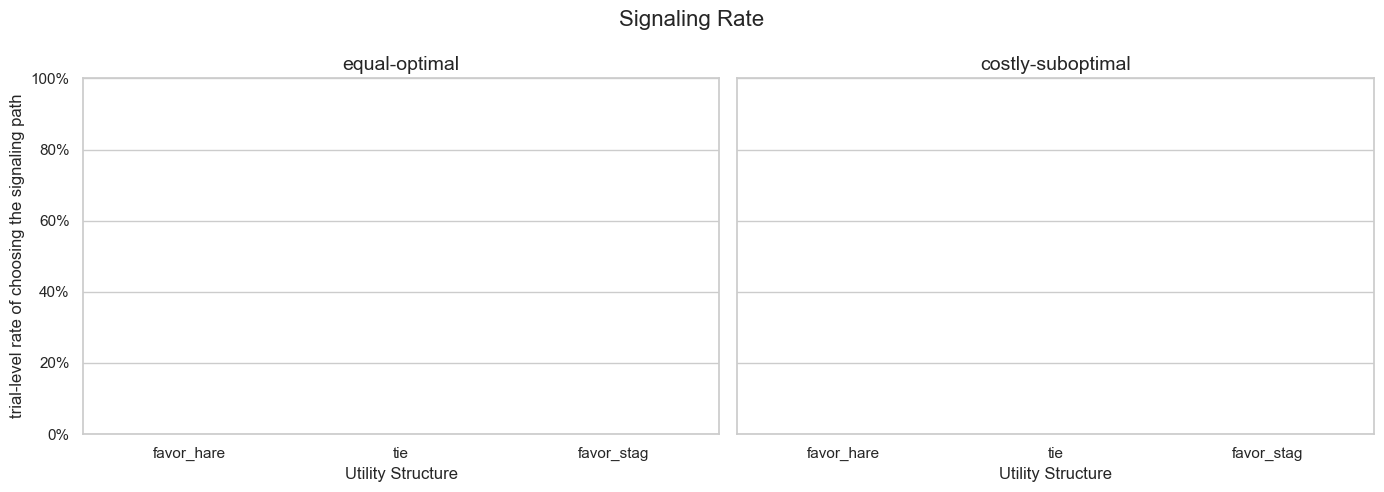

Saved generated/stag_hunt_vlm_vs_vlm_n5/signaling_rate_by_path_and_utility.png


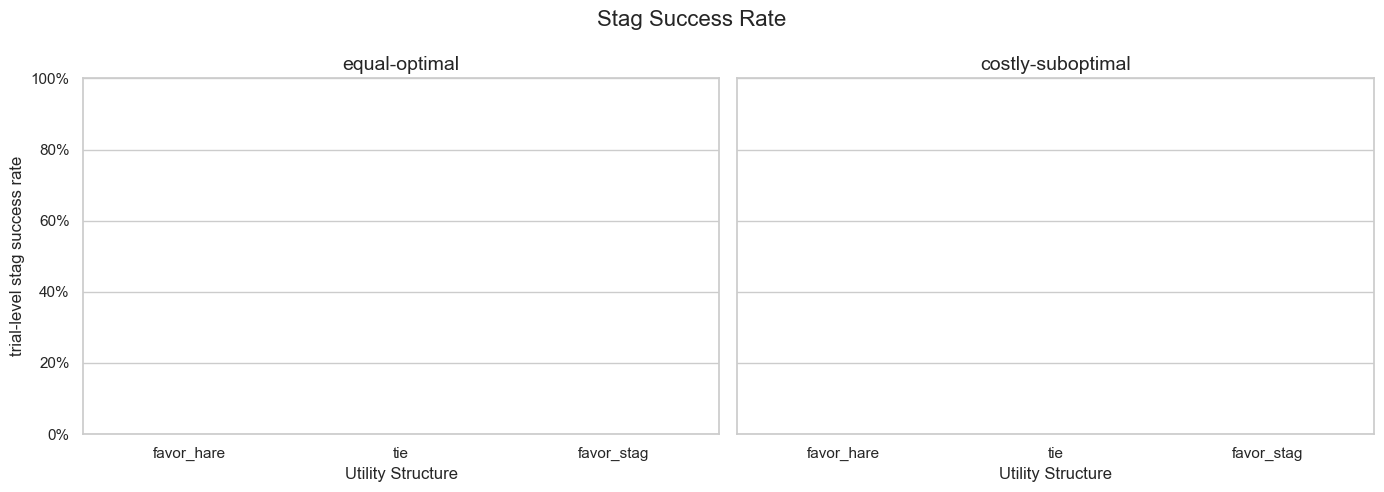

Saved generated/stag_hunt_vlm_vs_vlm_n5/stag_success_rate_by_path_and_utility.png


In [4]:
rate_metrics = [
    ('signalingRate', 'Signaling Rate', 'trial-level rate of choosing the signaling path', 'signaling_rate_by_path_and_utility.png'),
    ('stagSuccessRate', 'Stag Success Rate', 'trial-level stag success rate', 'stag_success_rate_by_path_and_utility.png')
]

for metric, title, y_label, filename in rate_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, path_type in zip(axes, PATH_TYPE_ORDER):
        sub = analysis_summary_df[analysis_summary_df['signalingPathType'] == path_type].copy()
        sns.barplot(
            data=sub,
            x='utilityStructure',
            y=metric,
            order=UTILITY_ORDER,
            palette=UTILITY_PALETTE,
            ax=ax
        )
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        ax.set_title(path_type)
        ax.set_xlabel('Utility Structure')
        ax.set_ylabel(y_label if ax is axes[0] else '')
    fig.suptitle(title)
    save_figure(fig, filename)


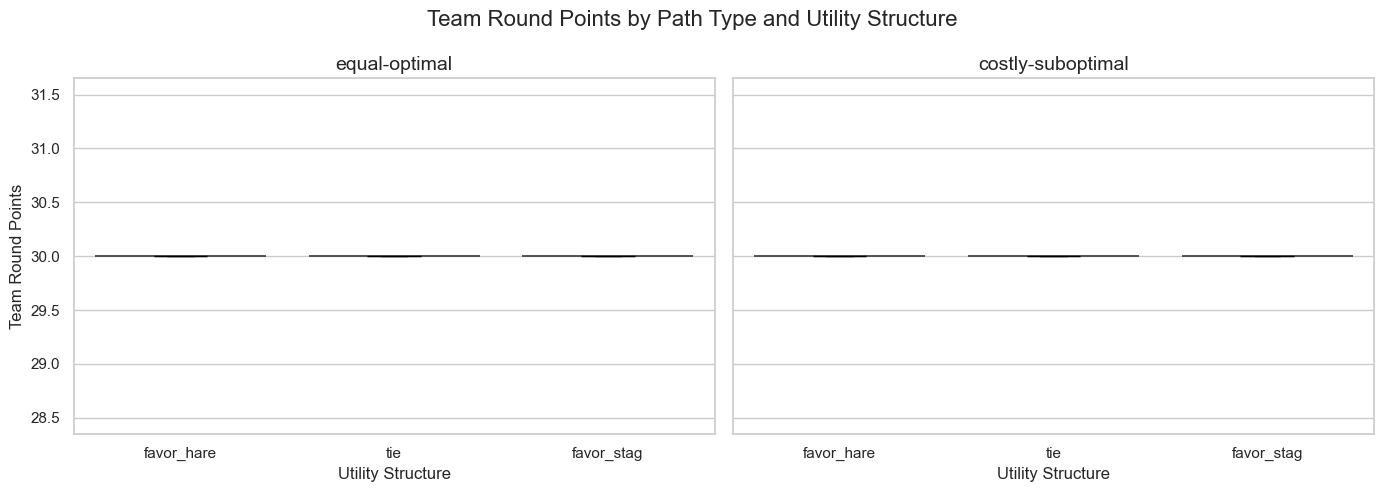

Saved generated/stag_hunt_vlm_vs_vlm_n5/team_round_points_by_path_and_utility.png


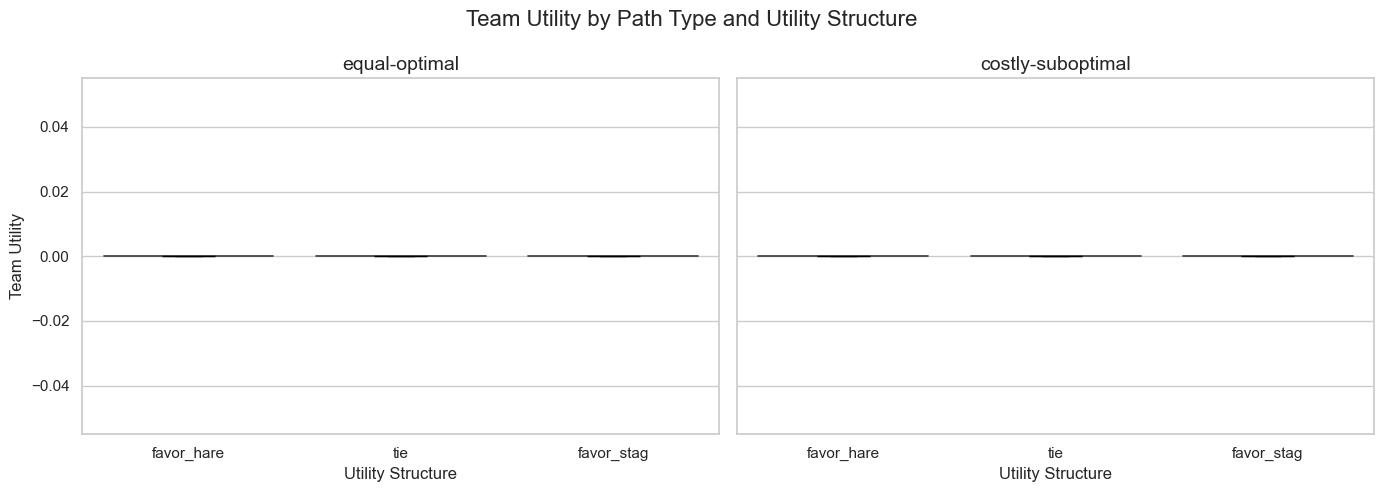

Saved generated/stag_hunt_vlm_vs_vlm_n5/team_utility_by_path_and_utility.png


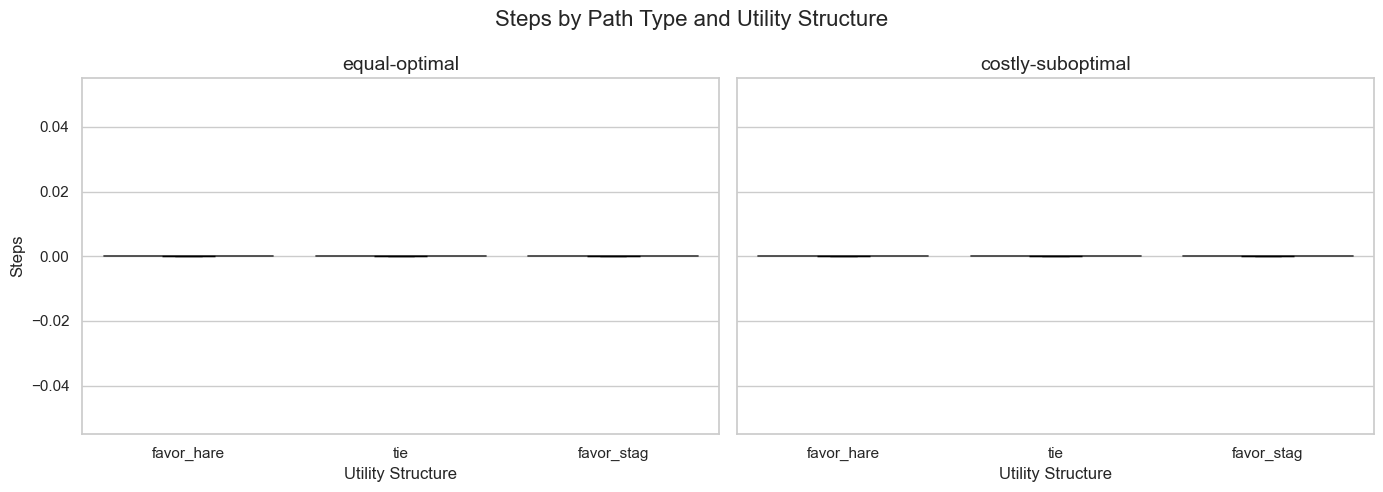

Saved generated/stag_hunt_vlm_vs_vlm_n5/steps_by_path_and_utility.png


In [5]:
distribution_specs = [
    ('teamRoundPoints', 'Team Round Points', 'team_round_points_by_path_and_utility.png'),
    ('teamUtility', 'Team Utility', 'team_utility_by_path_and_utility.png'),
    ('steps', 'Steps', 'steps_by_path_and_utility.png')
]

for metric, title, filename in distribution_specs:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, path_type in zip(axes, PATH_TYPE_ORDER):
        sub = trial_df[trial_df['signalingPathType'] == path_type].copy()
        sns.violinplot(
            data=sub,
            x='utilityStructure',
            y=metric,
            order=UTILITY_ORDER,
            palette=UTILITY_PALETTE,
            inner=None,
            cut=0,
            ax=ax
        )
        sns.boxplot(
            data=sub,
            x='utilityStructure',
            y=metric,
            order=UTILITY_ORDER,
            showcaps=True,
            boxprops={'facecolor': 'white', 'alpha': 0.6},
            whiskerprops={'linewidth': 1},
            medianprops={'color': 'black'},
            showfliers=False,
            width=0.25,
            ax=ax
        )
        ax.set_title(path_type)
        ax.set_xlabel('Utility Structure')
        ax.set_ylabel(title if ax is axes[0] else '')
    fig.suptitle(f'{title} by Path Type and Utility Structure')
    save_figure(fig, filename)


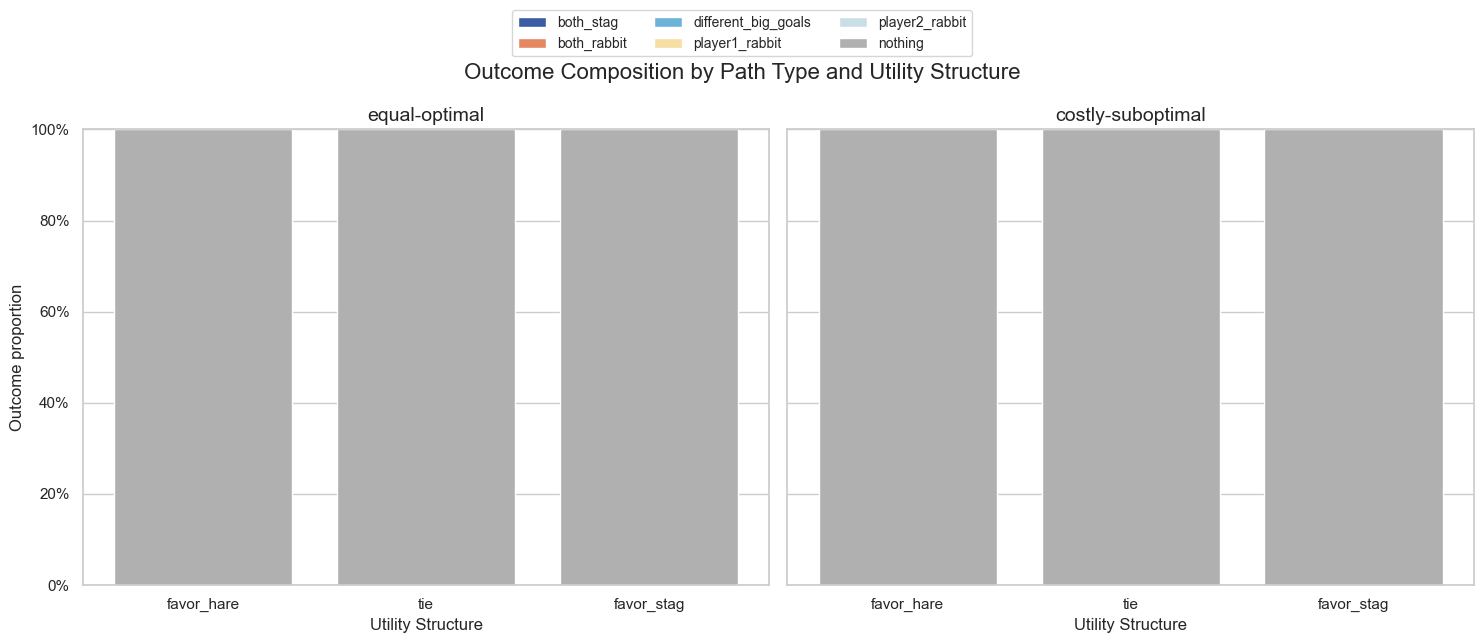

Saved generated/stag_hunt_vlm_vs_vlm_n5/outcome_composition_by_path_and_utility.png


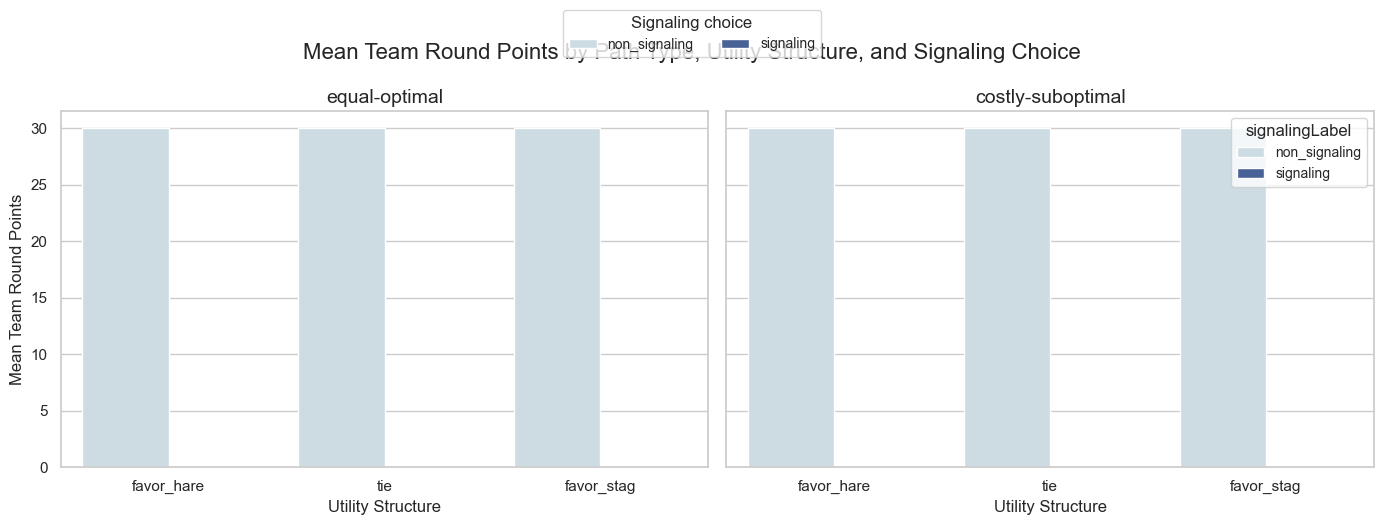

Saved generated/stag_hunt_vlm_vs_vlm_n5/team_points_signaling_vs_non_signaling_by_path_and_utility.png


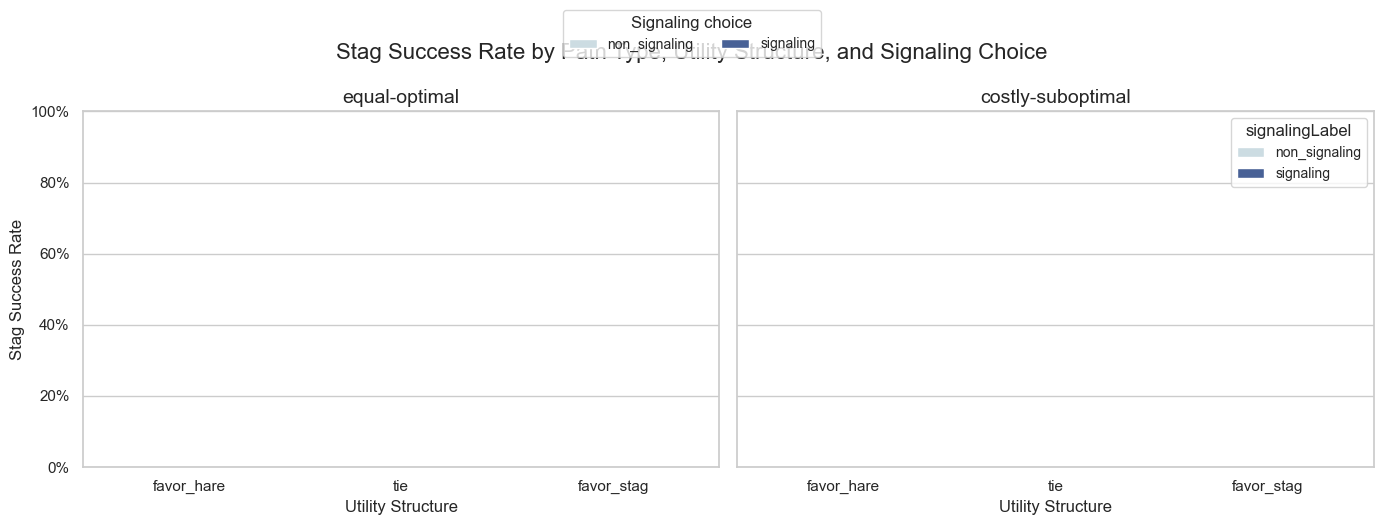

Saved generated/stag_hunt_vlm_vs_vlm_n5/stag_success_signaling_vs_non_signaling_by_path_and_utility.png


In [6]:
outcome_plot_df = outcome_summary.copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for ax, path_type in zip(axes, PATH_TYPE_ORDER):
    sub = outcome_plot_df[outcome_plot_df['signalingPathType'] == path_type].copy()
    pivot = sub.pivot_table(index='utilityStructure', columns='outcomeCategory', values='proportion', fill_value=0)
    pivot = pivot.reindex(index=UTILITY_ORDER, columns=OUTCOME_ORDER, fill_value=0)
    bottom = np.zeros(len(pivot))
    x = np.arange(len(pivot.index))
    for outcome in OUTCOME_ORDER:
        values = pivot[outcome].to_numpy()
        ax.bar(x, values, bottom=bottom, color=OUTCOME_PALETTE[outcome], label=outcome)
        bottom = bottom + values
    ax.set_xticks(x)
    ax.set_xticklabels(UTILITY_ORDER)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title(path_type)
    ax.set_xlabel('Utility Structure')
    ax.set_ylabel('Outcome proportion' if ax is axes[0] else '')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=3)
fig.suptitle('Outcome Composition by Path Type and Utility Structure')
save_figure(fig, 'outcome_composition_by_path_and_utility.png')

comparison_specs = [
    ('meanTeamRoundPoints', 'Mean Team Round Points', 'team_points_signaling_vs_non_signaling_by_path_and_utility.png', False),
    ('stagSuccessRate', 'Stag Success Rate', 'stag_success_signaling_vs_non_signaling_by_path_and_utility.png', True)
]

for metric, title, filename, is_rate in comparison_specs:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, path_type in zip(axes, PATH_TYPE_ORDER):
        sub = signal_comparison_df[signal_comparison_df['signalingPathType'] == path_type].copy()
        sns.barplot(
            data=sub,
            x='utilityStructure',
            y=metric,
            hue='signalingLabel',
            order=UTILITY_ORDER,
            hue_order=SIGNALING_ORDER,
            palette=SIGNALING_PALETTE,
            ax=ax
        )
        ax.set_title(path_type)
        ax.set_xlabel('Utility Structure')
        ax.set_ylabel(title if ax is axes[0] else '')
        if is_rate:
            ax.set_ylim(0, 1)
            ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
        if ax is not axes[1]:
            ax.legend_.remove()
    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.06), ncol=2, title='Signaling choice')
    fig.suptitle(title + ' by Path Type, Utility Structure, and Signaling Choice')
    save_figure(fig, filename)


## 5. Python to R Bridge

In [7]:
# Point rpy2 at the system R, matching the adults notebook pattern.
os.environ['R_HOME'] = '/Library/Frameworks/R.framework/Resources'
os.environ['R_LIBS_USER'] = '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library'

%load_ext rpy2.ipython

r_analysis_df = trial_df.copy()
r_analysis_df['utilityStructure'] = r_analysis_df['utilityStructure'].astype(str)
r_analysis_df['signalingPathType'] = r_analysis_df['signalingPathType'].astype(str)
r_analysis_df['signalingLabel'] = r_analysis_df['signalingLabel'].astype(str)
print(f'r_analysis_df: {r_analysis_df.shape}')


During startup - Warning messages:
1: Setting LC_CTYPE failed, using "C" 
2: Setting LC_COLLATE failed, using "C" 
3: Setting LC_TIME failed, using "C" 
4: Setting LC_MESSAGES failed, using "C" 
5: Setting LC_MONETARY failed, using "C" 


r_analysis_df: (90, 71)


## 6. R Mixed-Effects Models by `signalingPathType`

In [8]:
%%R -i r_analysis_df
suppressPackageStartupMessages({
  library(lme4)
  library(lmerTest)
  library(dplyr)
  library(readr)
  library(ggplot2)
  library(emmeans)
  library(car)
})

options(readr.show_col_types = FALSE)
options(width = 180)
has_blme <- requireNamespace('blme', quietly = TRUE)

fit_logit_mixed <- function(formula, data) {
  fit_glmer <- function() {
    glmer(
      formula,
      data = data,
      family = binomial(link = 'logit'),
      control = glmerControl(optimizer = 'bobyqa', optCtrl = list(maxfun = 2e5))
    )
  }

  if (has_blme) {
    tryCatch(
      blme::bglmer(
        formula,
        data = data,
        family = binomial(link = 'logit'),
        fixef.prior = normal,
        cov.prior = NULL
      ),
      error = function(e) {
        cat(sprintf('blme::bglmer failed (%s); falling back to glmer\n', conditionMessage(e)))
        fit_glmer()
      }
    )
  } else {
    cat('blme not available; using glmer\n')
    fit_glmer()
  }
}

fit_linear_mixed <- function(formula, data) {
  lmer(
    formula,
    data = data,
    REML = FALSE,
    control = lmerControl(optimizer = 'bobyqa', optCtrl = list(maxfun = 2e5))
  )
}

safe_car_anova <- function(model) {
  tryCatch(
    capture.output(print(car::Anova(model))),
    error = function(e) sprintf('Anova unavailable: %s', conditionMessage(e))
  )
}

safe_emmeans <- function(model, spec, type = 'response') {
  tryCatch(
    as.data.frame(summary(emmeans(model, spec, type = type))),
    error = function(e) {
      cat(sprintf('emmeans unavailable: %s\n', conditionMessage(e)))
      NULL
    }
  )
}

safe_fit_linear_mixed <- function(formula, data, label) {
  tryCatch(
    fit_linear_mixed(formula, data),
    error = function(e) {
      cat(sprintf('%s fit failed: %s\n', label, conditionMessage(e)))
      NULL
    }
  )
}

safe_report_model <- function(model, label, spec = NULL, type = 'response') {
  if (is.null(model)) {
    return(invisible(NULL))
  }

  tryCatch(
    print(summary(model)),
    error = function(e) cat(sprintf('%s summary unavailable: %s\n', label, conditionMessage(e)))
  )
  cat(paste(safe_car_anova(model), collapse = '\n'), '\n')

  if (!is.null(spec)) {
    emm <- safe_emmeans(model, spec, type = type)
    if (!is.null(emm)) {
      cat(sprintf('\nEstimated marginal means (%s):\n', label))
      print(emm)
    }
  }
}

df_trial <- r_analysis_df %>%
  mutate(
    runId = as.factor(runId),
    signalingPathType = factor(signalingPathType, levels = c('equal-optimal', 'costly-suboptimal')),
    utilityStructure = factor(utilityStructure, levels = c('favor_hare', 'tie', 'favor_stag')),
    signalerChoseSignalingPath = as.numeric(signalerChoseSignalingPath),
    stagHuntSuccess = as.numeric(stagHuntSuccess)
  )

for (pt in levels(df_trial$signalingPathType)) {
  cat('\n', strrep('=', 100), '\n', sep = '')
  cat('PATH TYPE:', pt, '\n')
  cat(strrep('=', 100), '\n', sep = '')
  df_sub <- df_trial %>% filter(signalingPathType == pt)
  print(df_sub %>% count(utilityStructure, signalerChoseSignalingPath, name = 'n'))

  cat('\n--- Signaling model ---\n')
  signal_counts <- sort(unique(df_sub$signalerChoseSignalingPath))
  if (length(signal_counts) < 2) {
    cat('Skipping signaling model: no variation in signaling outcome.\n')
  } else {
    model_signal <- tryCatch(
      fit_logit_mixed(signalerChoseSignalingPath ~ utilityStructure + (1 | runId), df_sub),
      error = function(e) {
        cat(sprintf('Signaling model failed: %s\n', conditionMessage(e)))
        NULL
      }
    )
    safe_report_model(model_signal, 'signaling model', ~ utilityStructure, type = 'response')
  }

  cat('\n--- Stag success model ---\n')
  success_counts <- sort(unique(df_sub$stagHuntSuccess))
  if (length(success_counts) < 2) {
    cat('Skipping success model: no variation in success outcome.\n')
  } else {
    model_success <- tryCatch(
      fit_logit_mixed(stagHuntSuccess ~ utilityStructure * signalerChoseSignalingPath + (1 | runId), df_sub),
      error = function(e) {
        cat(sprintf('Success model failed: %s\n', conditionMessage(e)))
        NULL
      }
    )
    safe_report_model(model_success, 'success model', ~ utilityStructure + signalerChoseSignalingPath, type = 'response')
  }

  cat('\n--- Team points model ---\n')
  model_points <- safe_fit_linear_mixed(
    teamRoundPoints ~ utilityStructure * signalerChoseSignalingPath + (1 | runId),
    df_sub,
    'Points model'
  )
  safe_report_model(model_points, 'points model', ~ utilityStructure + signalerChoseSignalingPath, type = 'response')

  cat('\n--- Team utility model ---\n')
  model_utility <- safe_fit_linear_mixed(
    teamUtility ~ utilityStructure * signalerChoseSignalingPath + (1 | runId),
    df_sub,
    'Utility model'
  )
  safe_report_model(model_utility, 'utility model', ~ utilityStructure + signalerChoseSignalingPath, type = 'response')
}


PATH TYPE:

equal-optimal

 utilityStructure

 signalerChoseSignalingPath

  n

...

Analysis of Deviance Table (Type II Wald chisquare tests)

Response: teamRoundPoints
                                             Chisq Df Pr(>Chisq)
utilityStructure                            0.3028  2     0.8595
signalerChoseSignalingPath                          0           
utilityStructure:signalerChoseSignalingPath         0           

emmeans unavailable: error in evaluating the argument 'object' in selecting a method for function 'summary': first argument must be a named list



--- Team utility model ---


Utility model fit failed: not a positive definite matrix (and positive semidefiniteness is not checked)


fixed-effect model matrix is rank deficient so dropping 3 columns / coefficients
fixed-effect model matrix is rank deficient so dropping 3 columns / coefficients
fixed-effect model matrix is rank deficient so dropping 3 columns / coefficients
fixed-effect model matrix is rank deficient so dropping 3 columns / coefficients
fixed-effect model matrix is rank deficient so dropping 3 columns / coefficients
fixed-effect model matrix is rank deficient so dropping 3 columns / coefficients
fixed-effect model matrix is rank deficient so dropping 3 columns / coefficients
fixed-effect model matrix is rank deficient so dropping 3 columns / coefficients
In addition: Warning messages:
1: In checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv,  :
  Model failed to converge with max|grad| = 2.59439 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.
2: In checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv,  :
  Model is nearly unidentifiable: very 

## 7. Conclusions

In [9]:
path_summary = analysis_summary_df[['signalingPathType', 'utilityStructure', 'signalingRate', 'stagSuccessRate', 'meanTeamRoundPoints', 'meanTeamUtility']].copy()

for path_type in PATH_TYPE_ORDER:
    sub = analysis_summary_df[analysis_summary_df['signalingPathType'] == path_type].copy()
    signal_trials = int(trial_df[(trial_df['signalingPathType'] == path_type) & (trial_df['signalerChoseSignalingPath'])].shape[0])
    total_trials = int(trial_df[trial_df['signalingPathType'] == path_type].shape[0])
    pooled_points = trial_df[trial_df['signalingPathType'] == path_type].groupby('signalerChoseSignalingPath')['teamRoundPoints'].mean()
    pooled_success = trial_df[trial_df['signalingPathType'] == path_type].groupby('signalerChoseSignalingPath')['stagHuntSuccessInt'].mean()

    print('\n' + '=' * 90)
    print(f'PATH TYPE: {path_type}')
    print('=' * 90)
    display(sub.round(4))
    print(f'Signaling trials: {signal_trials} / {total_trials}')
    if True in pooled_points.index and False in pooled_points.index:
        print(f'Signaling minus non-signaling team-point difference: {pooled_points[True] - pooled_points[False]:.3f}')
    if True in pooled_success.index and False in pooled_success.index:
        print(f'Signaling minus non-signaling stag-success difference: {pooled_success[True] - pooled_success[False]:.3f}')
    if signal_trials < 5:
        print('Caveat: very few signaling trials in this path type; mixed-effects signaling terms may be unstable.')

print('\n' + '=' * 90)
print('POOLED SUMMARY')
print('=' * 90)
print(f"Overall mean team round points: {trial_df['teamRoundPoints'].mean():.3f}")
print(f"Overall mean team utility: {trial_df['teamUtility'].mean():.3f}")
print(f"Overall signaling rate: {trial_df['signalerChoseSignalingPathInt'].mean():.3f}")
print(f"Overall stag success rate: {trial_df['stagHuntSuccessInt'].mean():.3f}")



PATH TYPE: equal-optimal


,signalingPathType,utilityStructure,trialCount,signalingRate,stagSuccessRate,meanTeamRoundPoints,meanTeamUtility,meanSteps,both_stagCount,both_rabbitCount,different_big_goalsCount,player1_rabbitCount,player2_rabbitCount,nothingCount
0,equal-optimal,favor_hare,15,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
1,equal-optimal,tie,15,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
2,equal-optimal,favor_stag,15,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0


Signaling trials: 0 / 45
Caveat: very few signaling trials in this path type; mixed-effects signaling terms may be unstable.

PATH TYPE: costly-suboptimal


,signalingPathType,utilityStructure,trialCount,signalingRate,stagSuccessRate,meanTeamRoundPoints,meanTeamUtility,meanSteps,both_stagCount,both_rabbitCount,different_big_goalsCount,player1_rabbitCount,player2_rabbitCount,nothingCount
3,costly-suboptimal,favor_hare,15,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
4,costly-suboptimal,tie,15,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
5,costly-suboptimal,favor_stag,15,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0


Signaling trials: 0 / 45
Caveat: very few signaling trials in this path type; mixed-effects signaling terms may be unstable.

POOLED SUMMARY
Overall mean team round points: 30.000
Overall mean team utility: 0.000
Overall signaling rate: 0.000
Overall stag success rate: 0.000
